In [100]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/zhome/71/c/146676/main/')
import SimpleITK as sitk
from loaders import loader_XA_to_NA
import importlib
importlib.reload(loader_XA_to_NA)
import tifffile
import SimpleITK
from loaders import stitcher_XA
from helpers import module_auxiliary as ma
from PIL import Image
import imageio.v3 as iio
Image.MAX_IMAGE_PIXELS = None 
from PIL import Image
import IPython.display as display
from scipy.ndimage import gaussian_filter
from scipy.ndimage import label, find_objects
!pip install matplotlib-scalebar
from matplotlib_scalebar.scalebar import ScaleBar
%matplotlib inline

In [2]:
# 15 distinct, bright RGB colors
import matplotlib.colors as mcolors
colors = [
    (255, 0, 0),      # Red
    (0, 255, 0),      # Green
    (0, 0, 255),      # Blue
    (255, 255, 0),    # Yellow
    (255, 165, 0),    # Orange
    (255, 0, 255),    # Magenta
    (0, 255, 255),    # Cyan
    (128, 0, 128),    # Purple
    (0, 128, 128),    # Teal
    (128, 128, 0),    # Olive
    (255, 105, 180),  # Pink
    (139, 69, 19),    # Brown
    (75, 0, 130),     # Indigo
    (0, 255, 127),     # Spring Green
    (127, 127, 127)   # Grey
]

# Convert to [0,1] scale for matplotlib
colors = [(r/255, g/255, b/255) for r, g, b in colors]
# Generate colormaps that transition from black to each color
colormaps = []
for color in colors:
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [(0, 0, 0), color])
    colormaps.append(cmap)


In [3]:
path = '/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/'
pre = 'Mosaic element_'
pre = 'eds'
images = []
names = [pre + 'Al.tiff', pre + 'Ca.tiff',pre + 'Cl.tiff', pre + 'Cr.tiff', pre + 'Fe.tiff',
                    pre + 'K.tiff', pre + 'Mg.tiff', pre + 'Na.tiff', pre + 'Ni.tiff',
                    pre + 'O.tiff', pre + 'P.tiff', pre + 'S.tiff', pre + 'Si.tiff',
                    pre + 'Ti.tiff', pre + 'Zr.tiff']
for i in range(len(names)):
    images.append(tifffile.imread(path + names[i]))
images = np.stack(images)
images = np.stack(images)
images[images>150]=0
images[0,images[0]>15]=0
images_d = images[:,::2,::2]
n_chan, ny, nx = np.shape(images_d)
factor = np.linspace(10,30,nx)
images_d[0] = images_d[0]*factor[np.newaxis,:]
factor = np.linspace(1,1.5,nx)
images_d[1:] = images_d[1:]*factor[np.newaxis, np.newaxis,:]
print(np.shape(images))

(15, 15484, 12341)


In [4]:
plt.close("all")
N = 15
#fig, axes = plt.subplots(3, 5, figsize=(25,15)) 
#fig.patch.set_facecolor('black')  # Set the background color to black


for i in range(N):
    
    i_x = i%5
    i_y = i//5
    #im0 = axes[i_y,i_x].imshow(images_d[i],cmap=colormaps[i])
    #axes[i_y,i_x].axis('off')
    # Add text in top-left corner

#plt.show(block=False)

In [5]:


## Uncomment this to see the bias
#nn = 8
#plt.imshow(images_d[nn]*factor[np.newaxis,:])
#plt.clim([0,30])
#plt.show()
#means = np.mean(factor[np.newaxis,:]*images_d[nn,3000:6000],axis=0)
#plt.plot(means)
#plt.show()

In [6]:
n_filter = 4
filters = [2, 5, 10, 20]
f_im = np.empty((n_filter, n_chan, ny, nx))
for i in range(n_filter):
    print('Applying filter with sd', filters[i])
    for j in range(n_chan):
        f_im[i, j, :,:] = gaussian_filter(images_d[j], sigma = filters[i])


Applying filter with sd 2
Applying filter with sd 5
Applying filter with sd 10
Applying filter with sd 20


Step 1, take only ::3 pixel in each direction. Size is larger than necessary.Step 2: Make a 4d array, where the 4th axis is the amount of smoothing done on the image....

In [7]:
elements = ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
                      #[Al, Ca, Cl, Cr, Fe,  K, Mg, Na, Ni,  O,  P,  S, Si, Ti, Zr]
thresholds = np.array([15, 15, 15, 10 , 20, 10, 30, 12, 5 , 30, 10, 13 , 92, 10, 1])
for i in range(n_chan):
    f_segm = f_im>thresholds[np.newaxis,:,np.newaxis, np.newaxis]

In [8]:
plt.close("all")
N = 15
#fig, axes = plt.subplots(N, 4, figsize=(20,int(20/4*N))) 
#fig.patch.set_facecolor('black')  # Set the background color to black


#for i in range(N):
#    for j in range(4):
#        im0 = axes[i,j].imshow(f_segm[j,i],cmap=colormaps[i])
#        axes[i,j].axis('off')
#        # Add text in top-left corner
#        axes[i,j].text(0, 0, elements[i] + '\nsd:\n' +str(filters[j]) + '\nth:\n' + str(thresholds[i]), color=colors[i], fontsize=10, ha="left", va="top", fontweight="bold")
#
#plt.show(block=False)

In [9]:
m_segm = f_segm[3]*f_segm[3]
elem_segm = {}
for i in range(n_chan):
    elem_segm[elements[i]] = m_segm[i]

elem_segm['Mg_high'] = f_im[3,6]>60
    
plt.close("all")
N = 15
#fig, axes = plt.subplots(3, 5, figsize=(25,15)) 
#fig.patch.set_facecolor('black')  # Set the background color to black


#for i in range(N):
#    
#    i_x = i%5
#    i_y = i//5
#    im0 = axes[i_y,i_x].imshow(m_segm[i],cmap=colormaps[i])
#    axes[i_y,i_x].axis('off')
#    # Add text in top-left corner
#    axes[i_y,i_x].text(0, 0, elements[i] + '\nth:\n' + str(thresholds[i]), color=colors[i], fontsize=10, ha="left", va="top", fontweight="bold")

# plt.show(block=False)

In [97]:
full_seg = np.zeros((ny,nx))
mask_feldspar_an_al = elem_segm["Al"]*elem_segm["Na"]*np.logical_not(elem_segm['Mg'])
mask_feldspar_al_or = np.logical_not(elem_segm['Mg'])*elem_segm['K']
mask_pyroxene_cpx = elem_segm["Ca"]
mask_pyroxene_opx = elem_segm['Mg_high']
mask_apatite = elem_segm['P']*elem_segm['Cl']*elem_segm['Ca']
mask_chromite = elem_segm['Cr']
mask_ilminite = elem_segm['Ti']
mask_pyrite = elem_segm['S']
mask_baddelyite = elem_segm['Zr']


In [101]:
def keep_largest_blobs(mask, num_blobs):
    # Label connected components
    labeled_mask, num_features = label(mask)
    
    # Get sizes of blobs
    blob_sizes = np.bincount(labeled_mask.ravel())[1:]  # Exclude background (label 0)
    
    if num_features == 0:
        return np.zeros_like(mask)  # No blobs found
    
    # Sort blobs by size (descending order) and get top N
    largest_blobs = np.argsort(blob_sizes)[::-1][:num_blobs] + 1  # +1 to match label indices
    
    # Create output mask with only the selected blobs
    output_mask = np.isin(labeled_mask, largest_blobs).astype(bool)
    
    return output_mask

In [102]:
mask_feldspar_an_al = keep_largest_blobs(mask_feldspar_an_al,60)
mask_feldspar_al_or = keep_largest_blobs(mask_feldspar_al_or,20)
mask_pyroxene_cpx = keep_largest_blobs(mask_pyroxene_cpx,8)
mask_pyroxene_opx = keep_largest_blobs(mask_pyroxene_opx,15)
mask_apatite = keep_largest_blobs(mask_apatite, 40)
mask_ilminite = keep_largest_blobs(mask_ilminite, 40)
mask_chromite = keep_largest_blobs(mask_chromite, 40)
mask_pyrite = keep_largest_blobs(mask_pyrite, 30)
mask_baddelyite = keep_largest_blobs(mask_baddelyite, 5)

masks = np.stack([mask_feldspar_an_al, mask_feldspar_al_or, mask_pyroxene_cpx, mask_pyroxene_opx, mask_apatite, mask_ilminite, mask_chromite, mask_pyrite, mask_baddelyite])

In [103]:
plt.close('all')
full_seg = np.zeros((ny,nx))
full_seg[mask_feldspar_an_al] =1
full_seg[mask_feldspar_al_or] =2
full_seg[mask_pyroxene_cpx] =3
full_seg[mask_pyroxene_opx] =4
full_seg[mask_apatite] =5
full_seg[mask_ilminite] = 6
full_seg[mask_chromite] = 7
full_seg[mask_pyrite] = 8
full_seg[mask_baddelyite] = 9


# Add black as the first color
colors_d = [
    (0, 0, 255),      # Blue Plagio
    (128, 0, 128),    # Purple Alk
    (255, 50, 150),   # Pink   #cpx
    (0, 255, 0),      # Green   # opx
    (255, 165, 0),    # Orange     #apatite
    (255, 255, 0),    # Yellow Ilminite
    (0, 170, 255),     # light blue, chromite
    (255, 0, 0),    #  pyrite   
    (255, 0, 255),   # Magenta, Baddelyite
]
#colors = [(0, 0, 0)] + colors
# Create a ListedColormap
colors_d = [(0, 0, 0)] + [(r/255, g/255, b/255) for r, g, b in colors_d]
cmap_d = mcolors.ListedColormap(colors_d)
boundaries = np.arange(-0.5, 10, 1)  # [-0.5, 0.5, 1.5, ..., 14.5]
norm = mcolors.BoundaryNorm(boundaries, cmap_d.N)
# Plot the matrix with the custom colormap

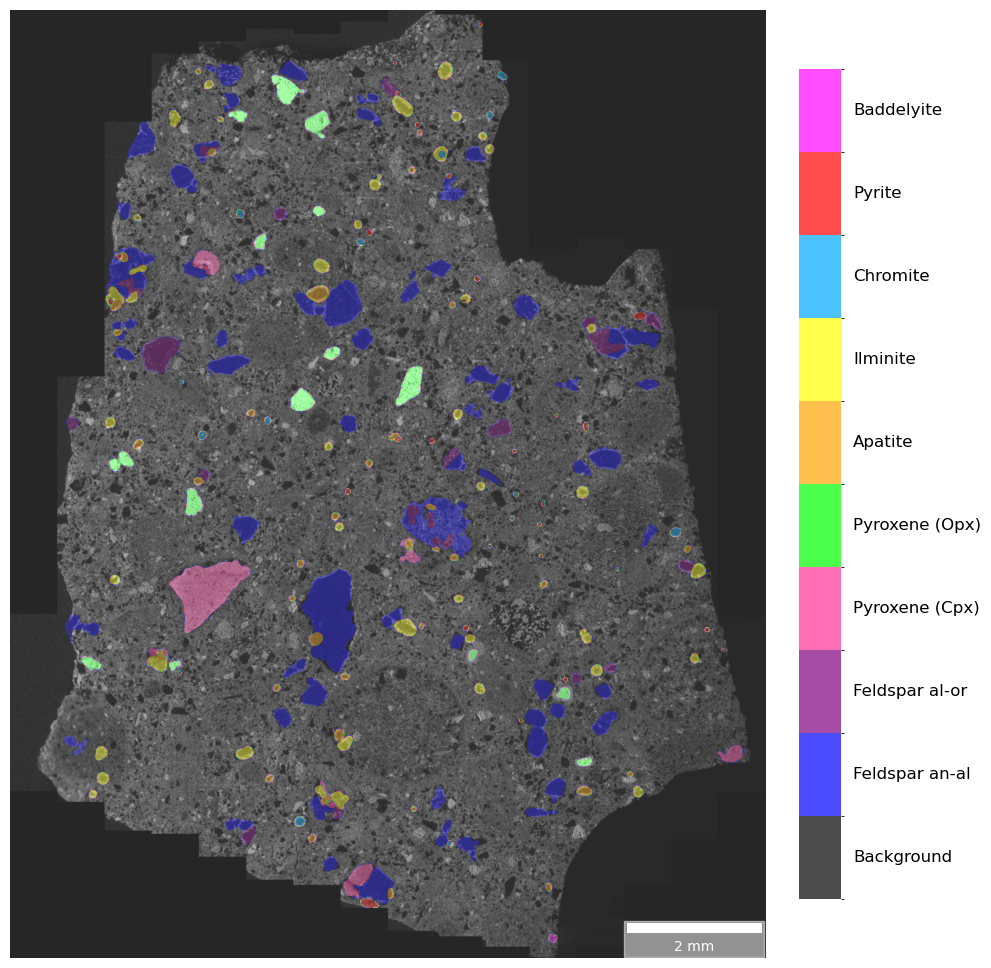

In [112]:
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 10))

im = ax.imshow(full_seg, cmap=cmap_d, norm=norm,  alpha=0.7)

# Create a colorbar next to the plot
cbar = fig.colorbar(im, ax=ax, ticks=[], fraction=0.05, pad=0.04)
bounds = np.arange(len(colors_d) + 1)  # Define color boundaries
# Manually add text labels next to the colorbar
class_labels=['Background', 'Feldspar an-al', 'Feldspar al-or', 'Pyroxene (Cpx)', 'Pyroxene (Opx)', 'Apatite', 'Ilminite', 'Chromite', 'Pyrite', 'Baddelyite']
cbar_ax = cbar.ax  # Get the colorbar axis
for i, label in enumerate(class_labels):
    y_pos = (bounds[i] + bounds[i + 1]-1) / 2  # Center text at each color
    cbar_ax.text(1.3, y_pos, label, va='center', ha='left', fontsize=12)

cbar_ax.set_frame_on(False)  # Remove border

# Overlay the grayscale image using transparency
ax.imshow(f_im[0,6], cmap="gray", alpha=0.5, vmin = 0, vmax = 100)  # Adjust alpha for blending

ax.axis('off')
# Add scale bar (adjust values based on real-world scale)
scalebar = ScaleBar(1.82, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
ax.add_artist(scalebar)
plt.tight_layout()
plt.savefig('plots/output_segm_full.png', bbox_inches='tight', dpi = 200)
plt.show()

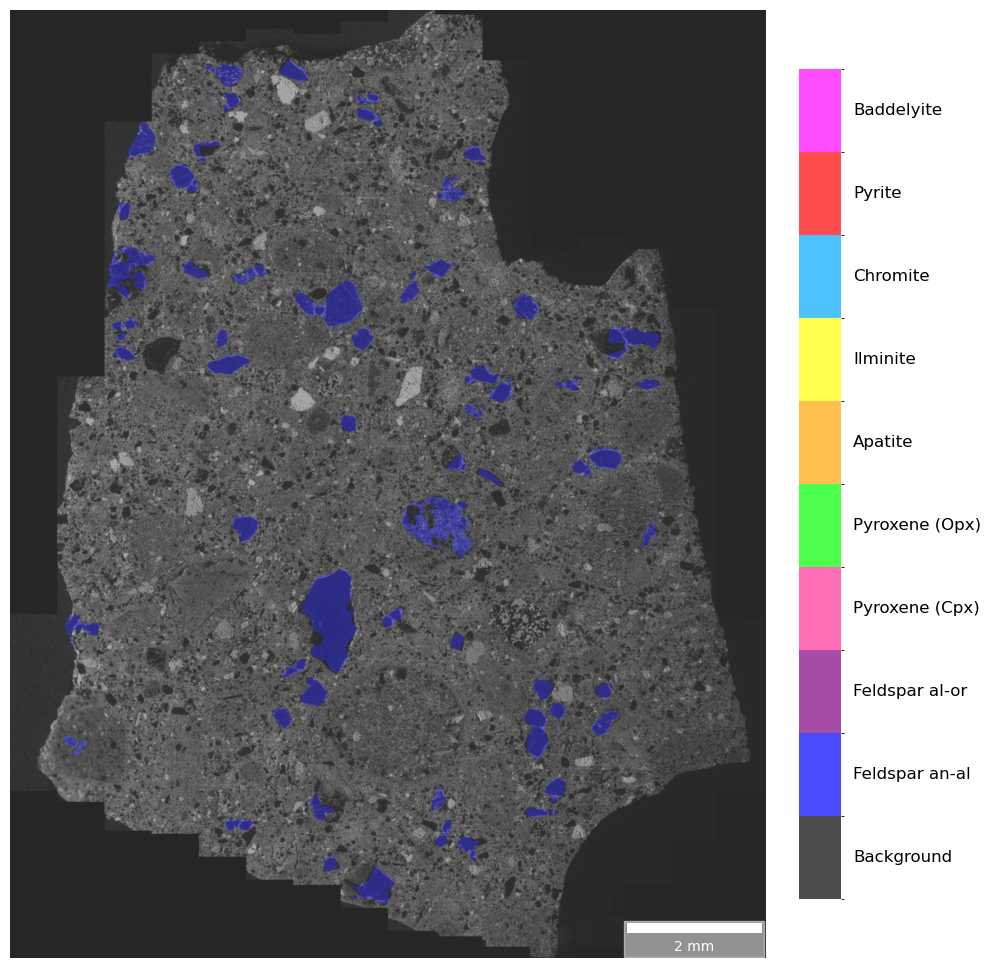

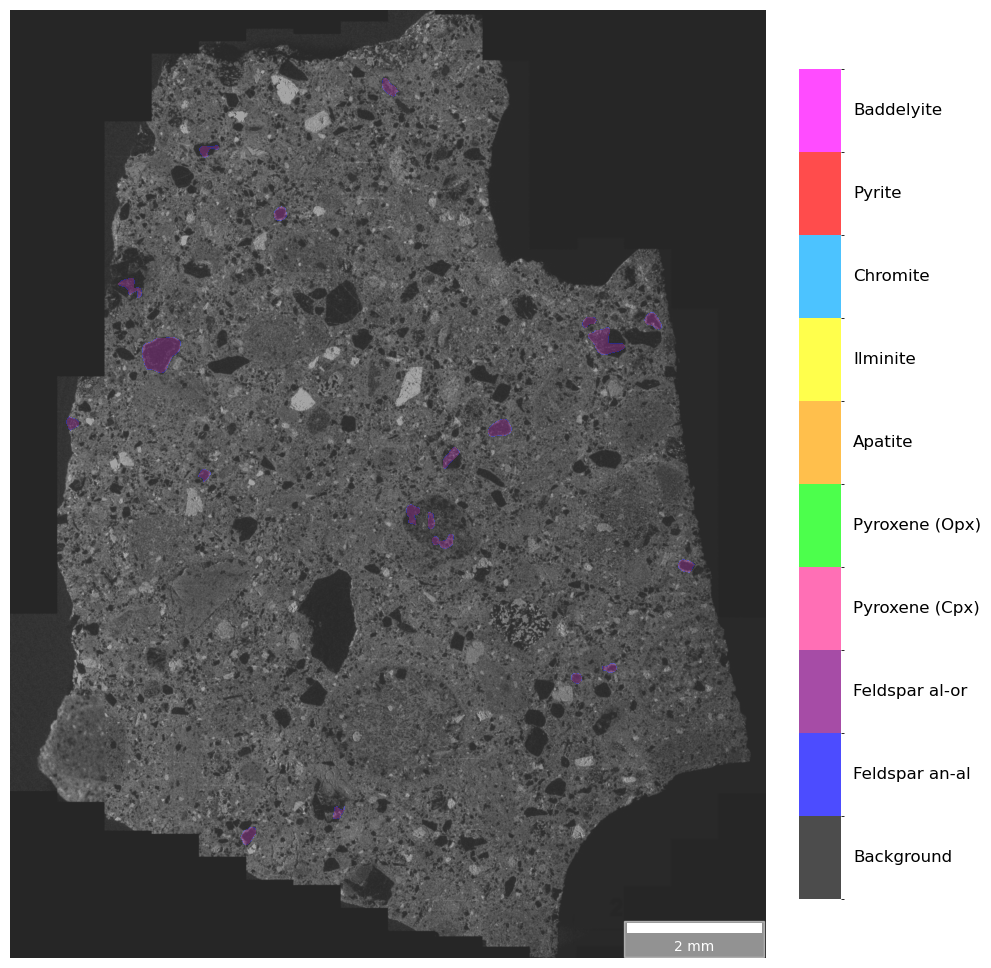

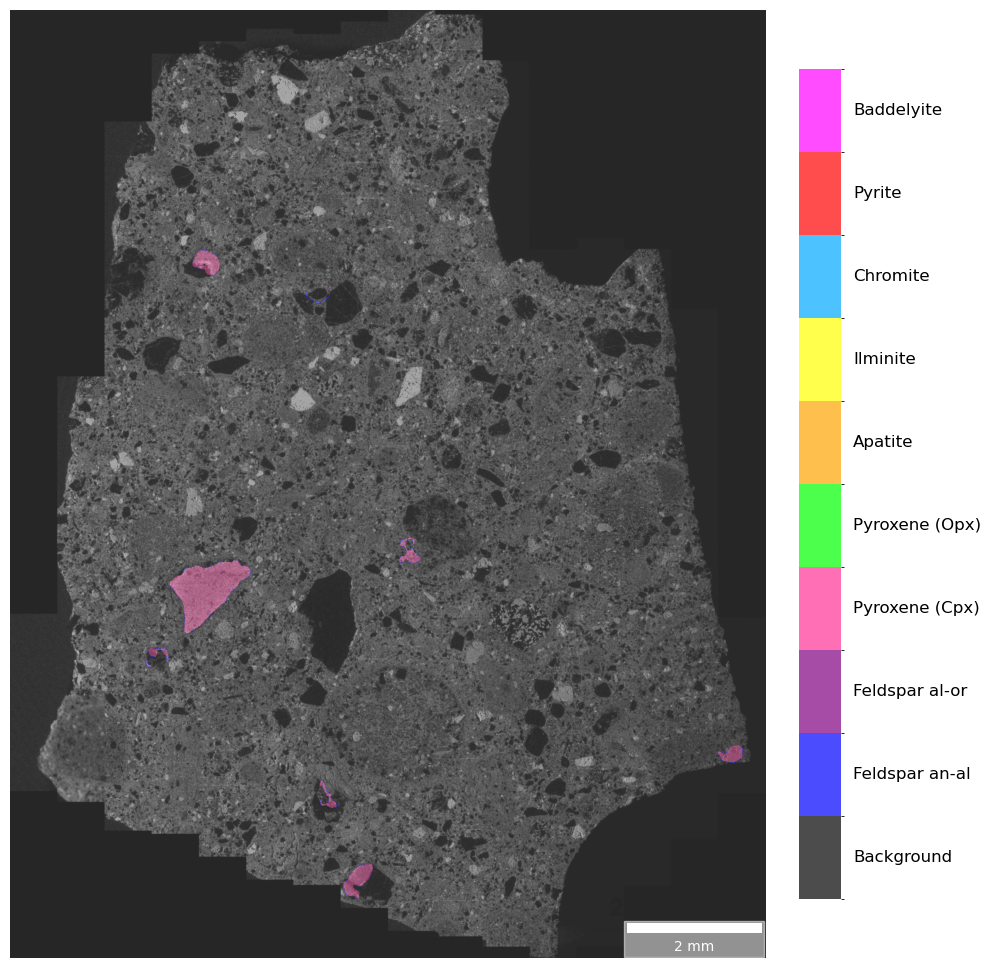

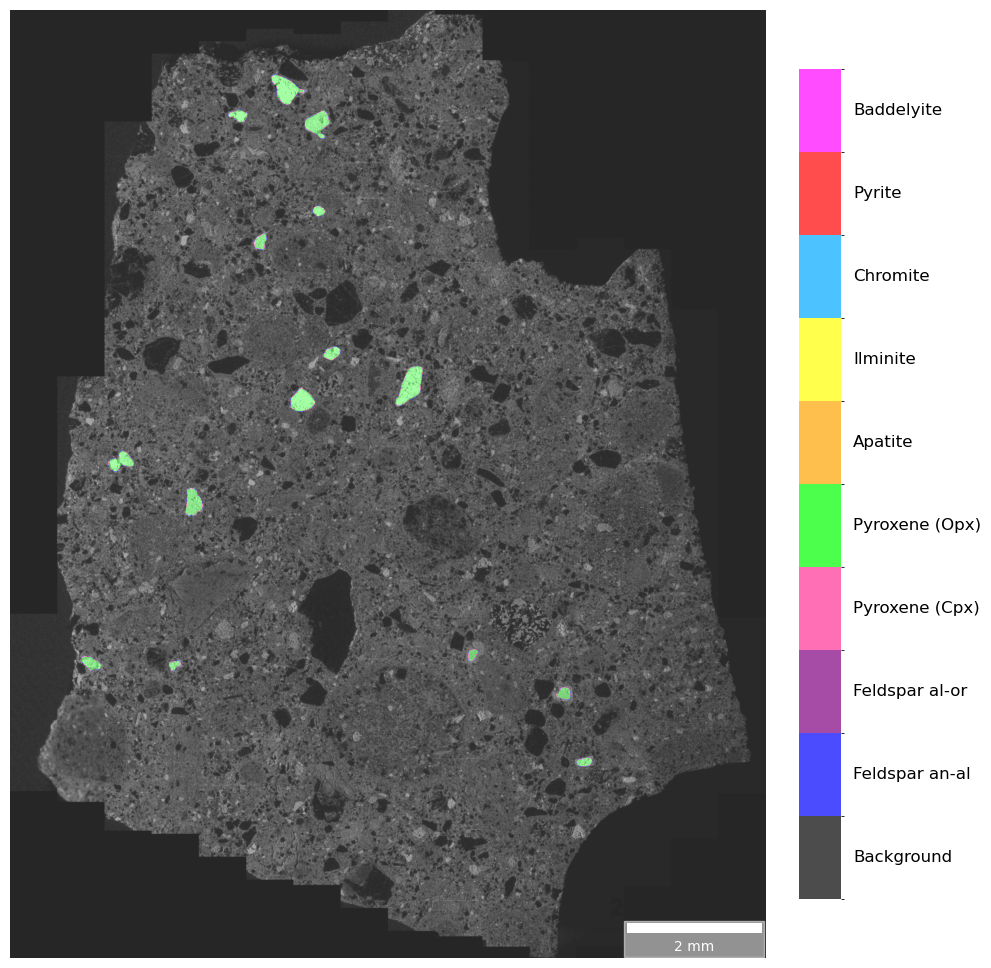

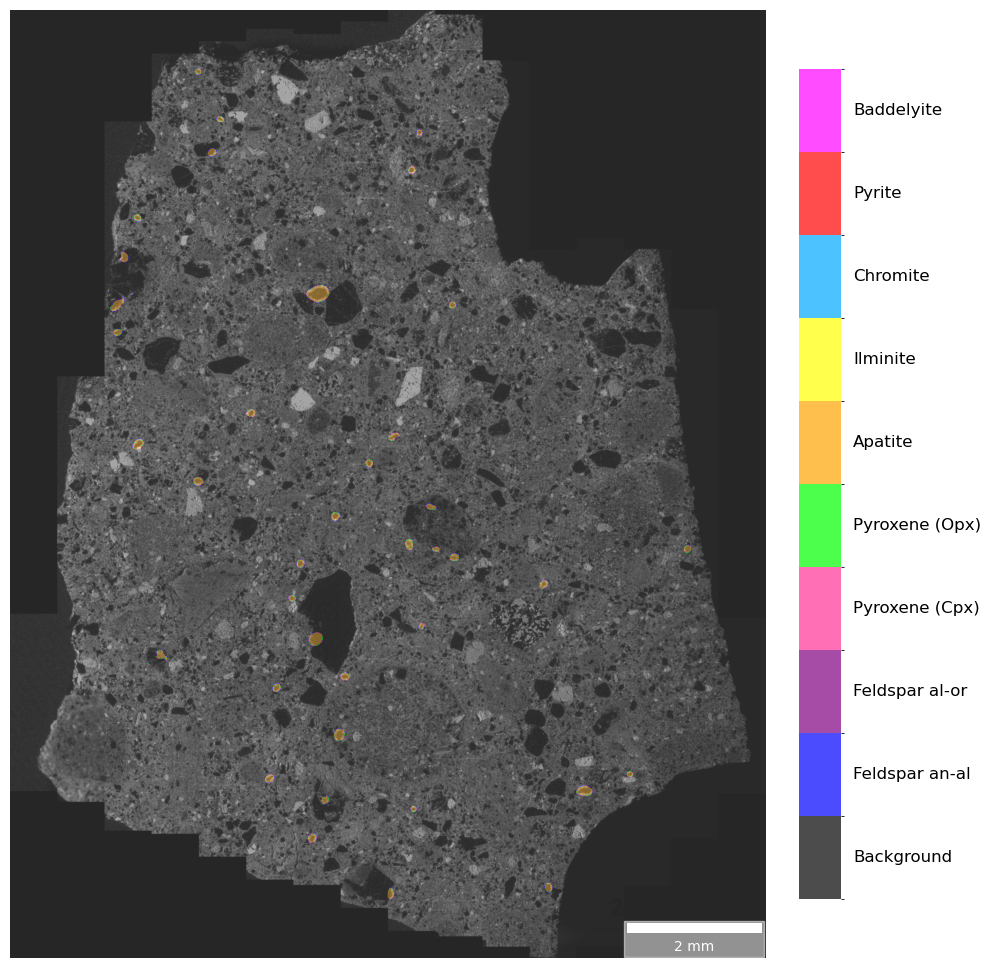

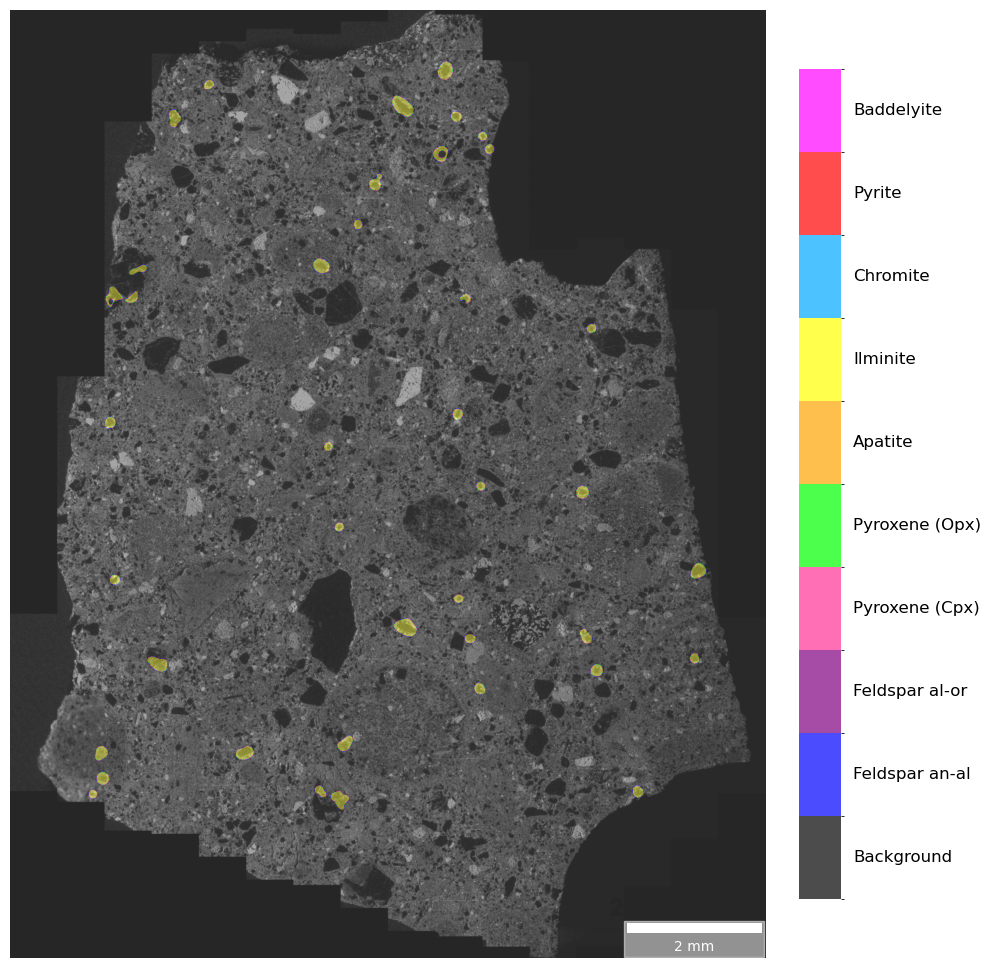

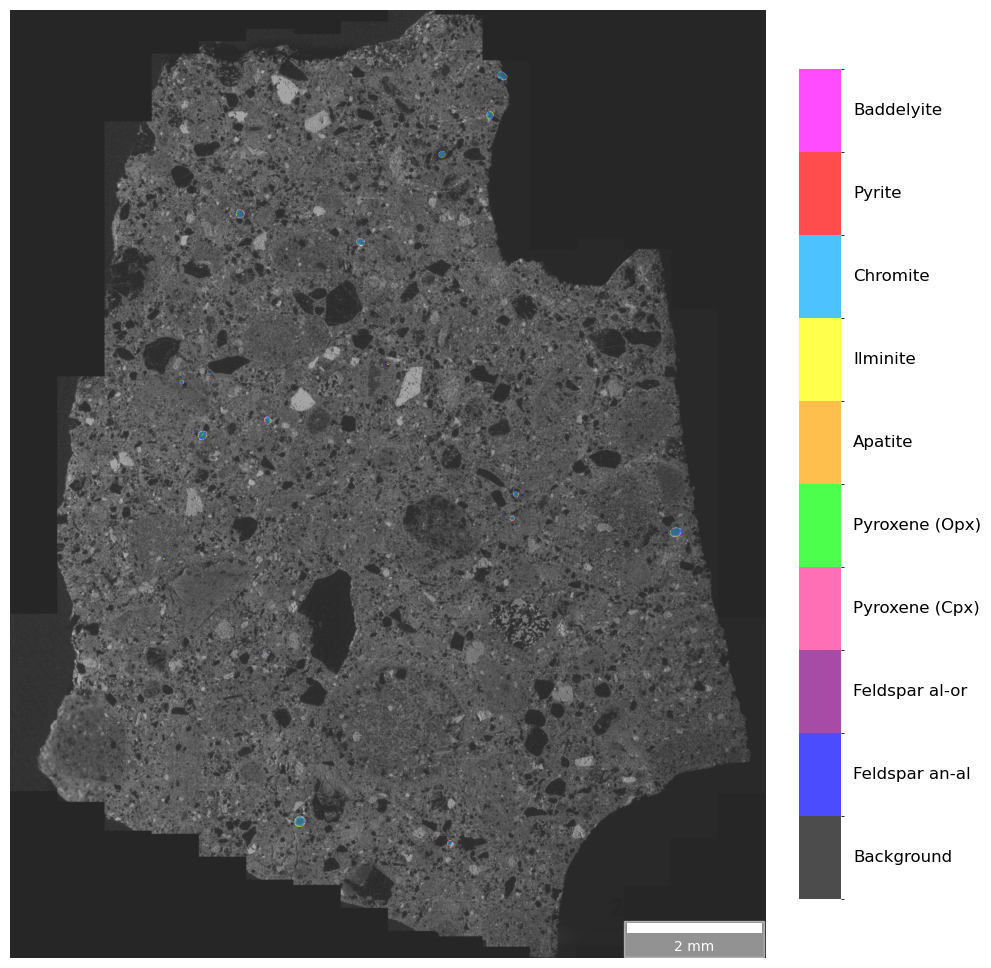

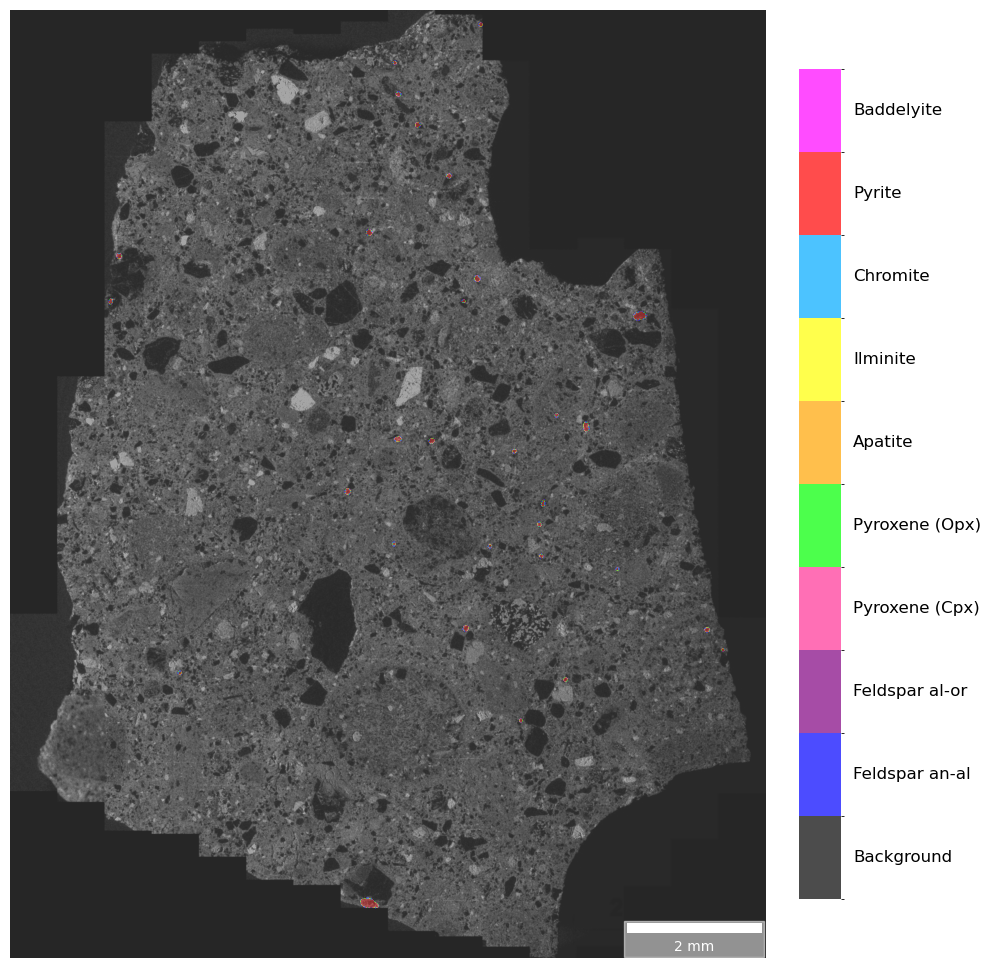

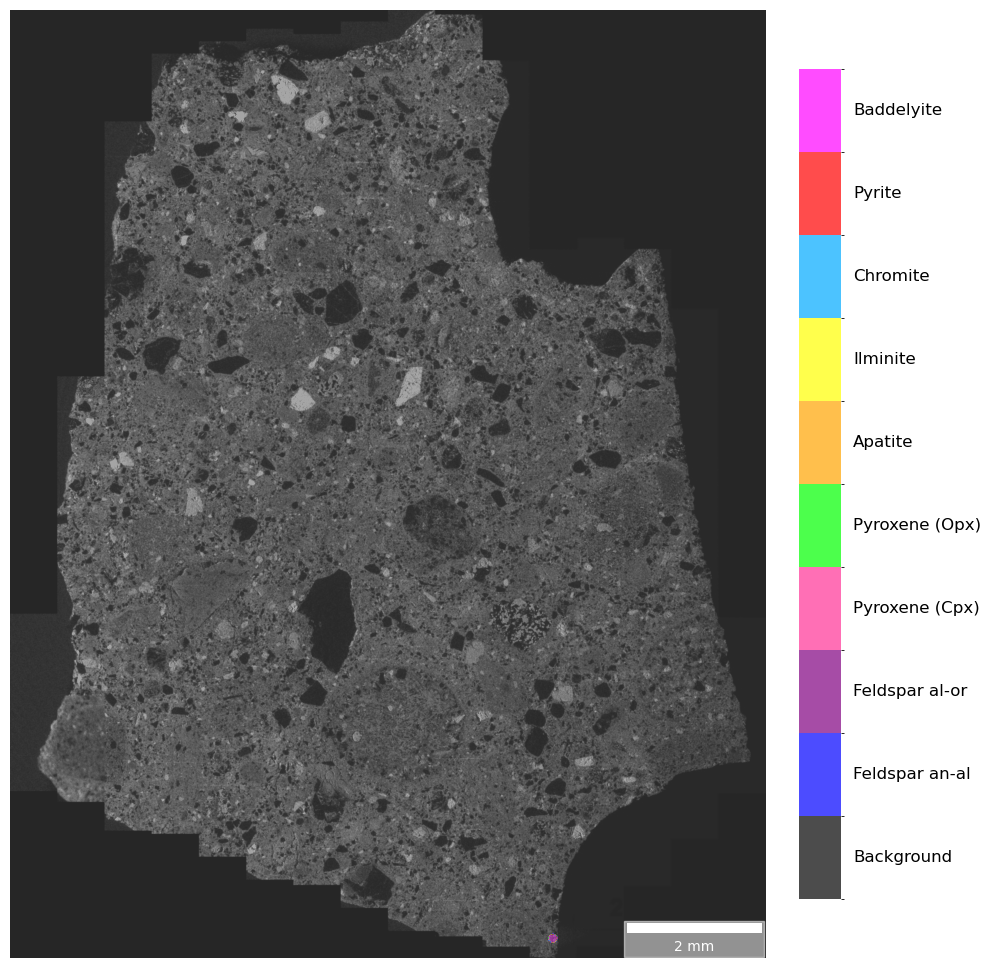

In [113]:
full_restr = np.zeros((ny,nx))

for i in range(1,10):
    full_restr[masks[i-1]] = i
    full_restr[np.logical_not(full_seg == i)] = 0

    #plt.close('all')
    fig, ax = plt.subplots(figsize=(10, 10))

    im = ax.imshow(full_restr, cmap=cmap_d, norm=norm,  alpha=0.7)

    # Create a colorbar next to the plot
    cbar = fig.colorbar(im, ax=ax, ticks=[], fraction=0.05, pad=0.04)
    bounds = np.arange(len(colors_d) + 1)  # Define color boundaries
    # Manually add text labels next to the colorbar
    class_labels=['Background', 'Feldspar an-al', 'Feldspar al-or', 'Pyroxene (Cpx)', 'Pyroxene (Opx)', 'Apatite', 'Ilminite', 'Chromite', 'Pyrite', 'Baddelyite']
    cbar_ax = cbar.ax  # Get the colorbar axis
    for j, label in enumerate(class_labels):
        y_pos = (bounds[j] + bounds[j + 1]-1) / 2  # Center text at each color
        cbar_ax.text(1.3, y_pos, label, va='center', ha='left', fontsize=12)

    cbar_ax.set_frame_on(False)  # Remove border

    # Overlay the grayscale image using transparency
    ax.imshow(f_im[0,6], cmap="gray", alpha=0.5, vmin = 0, vmax = 100)  # Adjust alpha for blending

    ax.axis('off')
    # Add scale bar (adjust values based on real-world scale)
    scalebar = ScaleBar(1.82, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
    ax.add_artist(scalebar)
    plt.tight_layout()
    plt.savefig('plots/output_segm' + str(i) + '.png', bbox_inches='tight', dpi=200)
    plt.show()

In [125]:
# Export the segmentations and labels

np.save('/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/segmentation_elements.npy', f_segm[3])

Some info regarding the elemental composition of minerals is needed:
Plagioclase (Albite-Anorthite). Mg-Al-Ca (on the slides). 

Albite (NaAlSi₃O₈),  (Al is an identifyer)
Anorthite (CaAl₂Si₂O₈) (Al is an identifyer)
Orthoclase (KAlSi₃O₈) (Al is an identifyer)
Clinopyroxene (Mg2 Si2 O6) or (Ca Mg Si2 O6), (Ca is a weak identifyer)
Orthopyroxene (Mg2 Si2 O6) or (Fe2 Si2 O6) (No clear identifyer discovered)
Chlorapatite (Ca5(PO4)3 Cl) (C + Cl + P) is a clear identifyer
Chromite (Fe Cr2 O4) (Cr is a unique identifyer, and Fe is also an identifyer)
Ilminite (Fe Ti O3) (Ti is a unique identifyer)
Pyrite (Fe S2) (S is a unique identifyer)

In [114]:
np.save('/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/segmentation.npy', full_seg)

In [10]:
#Ordering of the elements:
#[Al, Ca, Cl, Cr, Fe, K, Mg, Na, Ni, O, P, S, Si, Ti, Zr]

Al, Ca, Cl, Cr, Fe, K, Mg, Na, Ni, O, P, S, Si, Ti, Zr = 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
albite = [1, Ca, Cl, Cr, Fe, K, Mg, 1, Ni, 8, P, S, 3, Ti, Zr]
anorthite = [2, 1, Cl, Cr, Fe, K, Mg, Na, Ni, 8, P, S, 2, Ti, Zr]
orthoclase = [1, Ca, Cl, Cr, Fe, 1, Mg, Na, Ni, 8, P, S, 3, Ti, Zr]
clinopyroxene = [Al, 1, Cl, Cr, Fe, K, 2, Na, Ni, 6, P, S, 2, Ti, Zr]
orthopyroxene = [Al, Ca, Cl, Cr, 2, K, 2, Na, Ni, 6, P, S, 2, Ti, Zr]
chlorapatite = [Al, 5, 2, Cr, Fe, K, Mg, Na, Ni, 12, 3, S, Si, Ti, Zr]
chromite = [Al, Ca, Cl, 2, 1, K, Mg, Na, Ni, 4, P, S, Si, Ti, Zr]
ilminite = [Al, Ca, Cl, Cr, 1, K, Mg, Na, Ni, 3, P, S, Si, 1, Zr]
pyrite = [Al, Ca, Cl, Cr, 1, K, Mg, Na, Ni, O, P, 2, Si, Ti, Zr]
nothing = [Al, Ca, Cl, Cr, Fe, K, Mg, Na, Ni, O, P, S, Si, Ti, Zr]
basis = np.array([albite, anorthite, orthoclase, clinopyroxene, orthopyroxene, chlorapatite, chromite, ilminite, pyrite, nothing])
